In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv('Social_Network_Ads.csv')

In [3]:
df=df.iloc[:,2:]

In [4]:
df.sample(5)

,Age,EstimatedSalary,Purchased
274,57,26000,1
168,29,148000,1
77,22,27000,0
356,54,70000,1
304,40,60000,0


<h1>EFFECT OF OUTLIERS</h1>

<h3>Adding outliers to understand</h3>

In [7]:
df = pd.concat([df,pd.DataFrame({'Age':[5,90,95],
                             'EstimatedSalary':[1000,250000,350000],
                             'Purchased':[0,1,1]})]
               ,ignore_index=True)

In [8]:
df

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0
...,...,...,...
398,36,33000,0
399,49,36000,1
400,5,1000,0
401,90,250000,1


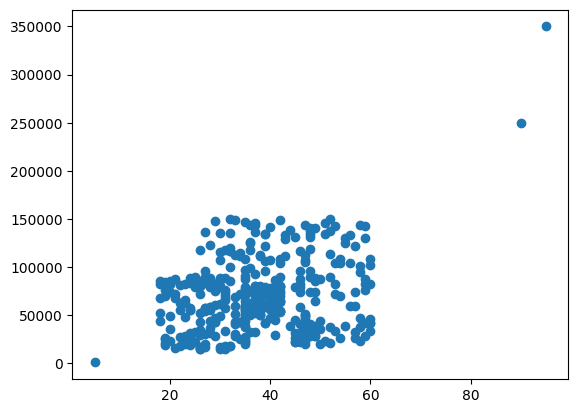

In [9]:
plt.scatter(data=df,x='Age',y='EstimatedSalary')

In [10]:
from sklearn.model_selection import train_test_split
x=df.drop(['Purchased'],axis=1)
y=df['Purchased']
x_train,x_test,y_train,y_test=train_test_split(x,
                                               y,
                                               test_size=0.3,
                                               random_state=0)
x_train.shape,x_test.shape

((282, 2), (121, 2))

In [12]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
scaler.fit(x_train)
x_train_scaled=scaler.transform(x_train)
x_test_scaled=scaler.transform(x_test)

In [14]:
x_train_scaled=pd.DataFrame(x_train_scaled,columns=x_train.columns)
x_test_scaled=pd.DataFrame(x_test_scaled,columns=x_test.columns)

In [16]:
x_train_scaled,x_test_scaled

(          Age  EstimatedSalary
 0   -0.652473        -0.995561
 1    1.903047         2.092697
 2   -0.104862         1.922701
 3   -0.652473         0.562734
 4   -0.013593        -0.287245
 ..        ...              ...
 277  0.899092        -1.108891
 278 -0.835010        -0.740567
 279 -0.196130        -0.485573
 280 -1.017547        -0.428908
 281 -1.108816         1.384381
 
 [282 rows x 2 columns],
           Age  EstimatedSalary
 0   -0.287399        -1.335552
 1    0.351481         0.166077
 2   -0.561205         1.356048
 3   -0.926279         0.506069
 4   -1.291353        -0.315577
 ..        ...              ...
 116 -0.287399        -1.250554
 117 -0.378667        -1.250554
 118 -0.287399        -0.542238
 119 -0.104862        -0.343910
 120  0.807824        -0.570571
 
 [121 rows x 2 columns])

Text(0.5, 1.0, 'After Scaling')

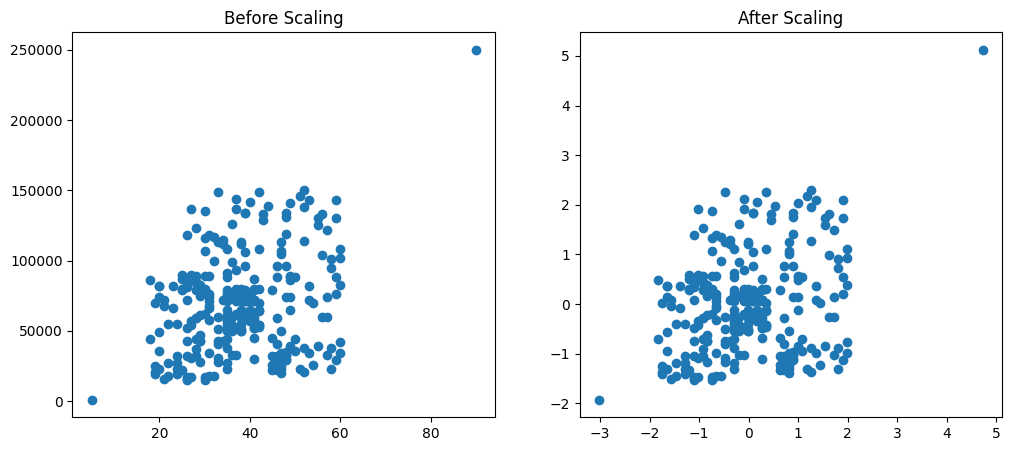

In [18]:
fig,(ax1,ax2)=plt.subplots(ncols=2,figsize=(12,5))

ax1.scatter(x_train['Age'],x_train['EstimatedSalary'])
ax1.set_title("Before Scaling")

ax2.scatter(x_train_scaled['Age'],x_train_scaled['EstimatedSalary'])
ax2.set_title("After Scaling")

<h3>Standardization changes the scale of data but does not eliminate the effect of outliers.</h3>